In [3]:
from pathlib import Path
import json
import torch

import numpy as np
import pandas as pd
from PIL import Image
import tensorflow as tf
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    confusion_matrix,
    precision_recall_curve
)

In [4]:
# -----------------------------
# paths
# -----------------------------
REPO_ROOT = Path("../..").resolve()

MANIFEST_PATH = (
    REPO_ROOT
    / "reports"
    / "manifests"
    / "broach_dataset_split_seed42.csv"
)

DATA_ROOT = REPO_ROOT / "data/03_broach_dataset"
TEST_DIR = DATA_ROOT / "test"

IMAGE_SIZE = (150, 100)

# outputs
OUTPUT_DIR = REPO_ROOT / "reports" 
OUTPUT_DIR.mkdir(exist_ok=True)

MODEL_PATH = REPO_ROOT / "models" / "ae_bn16_broach_dataset_PyTorch_20260709.pth"

SCORES_PATH = OUTPUT_DIR / "SVE" / "ae_scores.csv"
THRESHOLD_PATH = OUTPUT_DIR / "SVE" / "ae_threshold.json"
METRICS_PATH = OUTPUT_DIR / "SVE" / "ae_metrics.csv"

val_df = pd.read_csv(OUTPUT_DIR / "val_scores_with_baselines.csv")
test_df = pd.read_csv(OUTPUT_DIR / "test_scores_with_baselines.csv")

In [5]:
def load_data_from_manifest(
    data_root: Path,
    manifest_csv: Path,
    split: str,
    target_size=(150, 100)
):
    df = pd.read_csv(manifest_csv)
    df_split = df[df["split"] == split].reset_index(drop=True)

    images, labels, filenames = [], [], []

    for _, row in tqdm(df_split.iterrows(), total=len(df_split)):
        filename = str(row["filename"])
        label = int(row["label"])

        folder = data_root / (
            "test" if split in ["test", "validation"] else "train"
        )

        file_path = folder / filename

        if not file_path.exists():
            print(f"Missing: {file_path}")
            continue

        img = (
            Image.open(file_path)
            .convert("RGB")
            .resize(target_size)
        )

        img = np.asarray(img, dtype=np.float32) / 255.0

        images.append(img)
        labels.append(label)
        filenames.append(filename)

    return (
        np.array(images),
        np.array(labels),
        np.array(filenames)
    )

class Autoencoder(torch.nn.Module):

    def __init__(self):
        super().__init__()

        # Encoder
        self.encoder_conv = torch.nn.Sequential(
            torch.nn.Conv2d(3, 4, kernel_size=3, padding=1),
            torch.nn.ReLU(),

            torch.nn.MaxPool2d(kernel_size=2, stride=2),

            torch.nn.Conv2d(4, 8, kernel_size=3, padding=1),
            torch.nn.ReLU(),

            torch.nn.MaxPool2d(kernel_size=(2, 3), stride=(2, 3)),

            torch.nn.Conv2d(8, 12, kernel_size=3, padding=1),
            torch.nn.ReLU()
        )

        self.flatten = torch.nn.Flatten()

        self.encoder_fc = torch.nn.Sequential(
            torch.nn.Linear(12 * 25 * 25, 16),
            torch.nn.ReLU()
        )

        # Decoder
        self.decoder_fc = torch.nn.Sequential(
            torch.nn.Linear(16, 12 * 25 * 25),
            torch.nn.ReLU()
        )

        self.decoder_conv = torch.nn.Sequential(
            torch.nn.Conv2d(12, 12, kernel_size=3, padding=1),
            torch.nn.ReLU(),

            torch.nn.Upsample(scale_factor=(2, 3), mode='nearest'),

            torch.nn.Conv2d(12, 8, kernel_size=3, padding=1),
            torch.nn.ReLU(),

            torch.nn.Upsample(scale_factor=(2, 2), mode='nearest'),

            torch.nn.Conv2d(8, 4, kernel_size=3, padding=1),
            torch.nn.ReLU(),

            torch.nn.Conv2d(4, 3, kernel_size=3, padding=1),
            torch.nn.Sigmoid()
        )

    def forward(self, x):

        x = self.encoder_conv(x)

        x = self.flatten(x)

        latent = self.encoder_fc(x)

        x = self.decoder_fc(latent)

        x = x.view(-1, 12, 25, 25)

        x = self.decoder_conv(x)

        return x

## Load data and reconstruct images 

In [6]:
# Load model
model = Autoencoder()

state_dict = torch.load(MODEL_PATH, map_location="cpu")
model.load_state_dict(state_dict)

model.eval()

Autoencoder(
  (encoder_conv): Sequential(
    (0): Conv2d(3, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(4, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=(2, 3), stride=(2, 3), padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(8, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (encoder_fc): Sequential(
    (0): Linear(in_features=7500, out_features=16, bias=True)
    (1): ReLU()
  )
  (decoder_fc): Sequential(
    (0): Linear(in_features=16, out_features=7500, bias=True)
    (1): ReLU()
  )
  (decoder_conv): Sequential(
    (0): Conv2d(12, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Upsample(scale_factor=(2.0, 3.0), mode='nearest')
    (3): Conv2d(12, 8, kernel_size=(3, 3), stride=(1, 1), pad

In [7]:
# Load images

X_val, y_val, f_val = load_data_from_manifest(
    DATA_ROOT,
    MANIFEST_PATH,
    "validation",
    IMAGE_SIZE
)

X_test, y_test, f_test = load_data_from_manifest(
    DATA_ROOT,
    MANIFEST_PATH,
    "test",
    IMAGE_SIZE
)

# PyTorch
X_val_torch = torch.from_numpy(X_val).permute(0, 3, 1, 2).float()
X_test_torch = torch.from_numpy(X_test).permute(0, 3, 1, 2).float()

print(X_val_torch.shape)
print(X_test_torch.shape)

  0%|          | 0/2500 [00:00<?, ?it/s]

100%|██████████| 2500/2500 [01:42<00:00, 24.47it/s] 


torch.Size([2500, 3, 100, 150])
torch.Size([2500, 3, 100, 150])


## Generate Error maps 

In [8]:
def compute_error_maps(model, images, batch_size=32):

    images_torch = (
        torch.from_numpy(images)
        .permute(0, 3, 1, 2)  # NHWC -> NCHW
        .float()
    )

    model.eval()
    recon_batches = []

    with torch.no_grad():
        for start in range(0, len(images_torch), batch_size):
            batch = images_torch[start:start + batch_size]

            recon = model(batch)

            recon_batches.append(
                recon.permute(0, 2, 3, 1).cpu().numpy()  # NCHW -> NHWC
            )

    recon = np.concatenate(recon_batches, axis=0)
    return (images - recon) ** 2


print("Computing error maps...")
val_error = compute_error_maps(model, X_val)
test_error = compute_error_maps(model, X_test)


Computing error maps...


## SVE flexible 
Sweeping Segment and top k amount to analyze detection behaviour.

In [9]:
def compute_sve_scores(error_map, n_segments, top_k):

    width = error_map.shape[2]
    boundaries = np.linspace(0, width, n_segments + 1, dtype=int)

    segments = []
    for l, r in zip(boundaries[:-1], boundaries[1:]):
        if r <= l:
            continue
        segments.append(
            error_map[:, :, l:r, :].mean(axis=(1,2,3))
        )

    segments = np.stack(segments, axis=1)
    sve_max = segments.max(axis=1)
    top_k = min(top_k, segments.shape[1])
    sve_topk = np.sort(segments, axis=1)[:, -top_k:].mean(axis=1)

    return sve_max, sve_topk

### Threshold & Evaluation function 


In [10]:
def select_best_f1_threshold(y_true, scores):
    precision, recall, thresholds = precision_recall_curve(y_true, scores)

    if len(thresholds) == 0:
        return float(np.max(scores))
    f1 = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)
    best_idx = int(np.nanargmax(f1))
    return float(thresholds[best_idx])


def evaluate(y_true, scores, threshold):
    y_pred = (scores >= threshold).astype(int)
    return {
        "pr_auc": average_precision_score(y_true, scores),
        "f1": f1_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
    }

## Sensitivity Grid 

Run sweeping on testset

In [19]:
segment_list = list(range(1, 30))
topk_list =  list(range(1, 11))#[1, 3, 5,10]

validation_results = []

for n_segments in segment_list:
    for top_k in topk_list:

        _, val_scores = compute_sve_scores(
            val_error,
            n_segments,
            top_k
        )

        threshold = select_best_f1_threshold(
            y_val,
            val_scores
        )

        metrics = evaluate(
            y_val,
            val_scores,
            threshold
        )

        validation_results.append({
            "segments": n_segments,
            "top_k": top_k,
            "threshold": threshold,
            "pr_auc": metrics["pr_auc"],
            "f1": metrics["f1"],
            "precision": metrics["precision"],
            "recall": metrics["recall"]
        })

validation_results_df = pd.DataFrame(validation_results)

## Select best configuration

In [20]:
best_row = validation_results_df.loc[
    validation_results_df["f1"].idxmax()
]

BEST_SEGMENTS = int(best_row["segments"])
BEST_TOPK = int(best_row["top_k"])
BEST_THRESHOLD = float(best_row["threshold"])

print(best_row)

segments     5.000000
top_k        1.000000
threshold    0.001871
pr_auc       0.891354
f1           0.840000
precision    0.777778
recall       0.913043
Name: 40, dtype: float64


### Evaluate on test set using best parameters vs. manual selected segments

In [23]:
# ------------------------------------------------------------
# Validation-selected configuration
# ------------------------------------------------------------

_, test_scores_validation = compute_sve_scores(
    test_error,
    BEST_SEGMENTS,
    BEST_TOPK,
)

test_metrics_validation = evaluate(
    y_test,
    test_scores_validation,
    BEST_THRESHOLD,
)

print("Validation-selected:")
print(test_metrics_validation)


# ------------------------------------------------------------
# Manual configuration
# ------------------------------------------------------------

MANUAL_SEGMENTS = 9
MANUAL_TOPK = 1

_, manual_val_scores = compute_sve_scores(
    val_error,
    MANUAL_SEGMENTS,
    MANUAL_TOPK,
)

MANUAL_THRESHOLD = select_best_f1_threshold(
    y_val,
    manual_val_scores,
)

_, test_scores_manual = compute_sve_scores(
    test_error,
    MANUAL_SEGMENTS,
    MANUAL_TOPK,
)

test_metrics_manual = evaluate(
    y_test,
    test_scores_manual,
    MANUAL_THRESHOLD,
)

print("Manual:")
print(test_metrics_manual)

Validation-selected:
{'pr_auc': 0.9450714087579344, 'f1': 0.9090909090909091, 'precision': 0.9090909090909091, 'recall': 0.9090909090909091}
Manual:
{'pr_auc': 0.9922595520421609, 'f1': 0.926829268292683, 'precision': 1.0, 'recall': 0.8636363636363636}


### PLot Results 

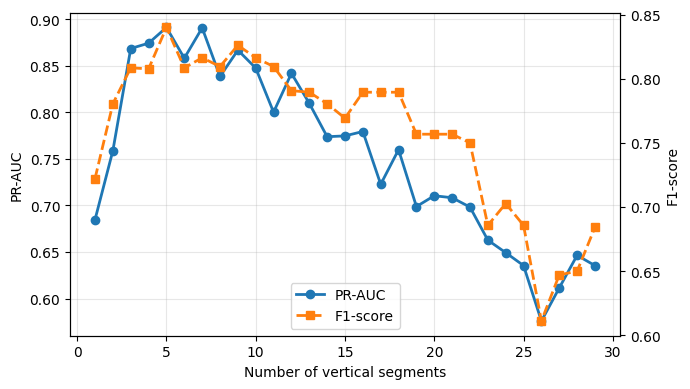

In [24]:
results_df = pd.DataFrame(validation_results)

plot_df = (
    validation_results_df[
        validation_results_df["top_k"] == BEST_TOPK
    ]
    .sort_values("segments")
)

fig, ax1 = plt.subplots(figsize=(7, 4))

# PR-AUC
line1 = ax1.plot(
    plot_df["segments"],
    plot_df["pr_auc"],
    marker="o",
    linewidth=2,
    label="PR-AUC"
)

ax1.set_xlabel("Number of vertical segments")
ax1.set_ylabel("PR-AUC")
ax1.grid(alpha=0.3)

# F1-Score
ax2 = ax1.twinx()

line2 = ax2.plot(
    plot_df["segments"],
    plot_df["f1"],
    marker="s",
    linewidth=2,
    linestyle="--",
    color="tab:orange",
    label="F1-score"
)

ax2.set_ylabel("F1-score")

# Legend
lines = line1 + line2
labels = [l.get_label() for l in lines]

ax1.legend(lines, labels, loc="lower center")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR /"SVE" /"sve_sensitivity_combined.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Save Results

In [27]:
validation_results_df.to_csv(
    OUTPUT_DIR / "SVE"/ "ae_metrics_sve_sensitivity.csv",
    index=False
)

comparison_scores = pd.DataFrame(
    {
        "label": y_test,
        "sve_manual_9": test_scores_manual,
        "sve_validation": test_scores_validation,
    }
)
comparison_scores["threshold_manual"] = MANUAL_THRESHOLD
comparison_scores["threshold_validation"] = BEST_THRESHOLD

comparison_scores.to_csv(
    OUTPUT_DIR / "SVE" / "sve_final_test_scores.csv",
    index=False,
)

In [26]:
pivot = validation_results_df.pivot(
    index="segments",
    columns="top_k",
    values="pr_auc"
)

pivot.to_csv(
    OUTPUT_DIR /"SVE" / "sve_sensitivity_matrix.csv"
)